# CdV Regimes with diffusion maps

In [ ]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib

importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [ ]:
from cdv_utils import (load_d, build_df, compute_eof,
                       plot_scatter, fit_hmm, compute_ftle_vectorized,
                       analyze_regime_escape_times, reconstruct_logs,
                       plot_density_heatmap)

## Regimes from deterministic dynamics

In [ ]:
dims = 6
sample_num = 200000
state_vector = load_d('./cdv_model/dataOro20.bin', dims, sample_num)

In [ ]:
from scipy.sparse.linalg import eigs  # for large sparse eigenproblems
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from scipy import sparse


def diffusion_maps_matrix(pts, epsilon):
    """
    pts: ndarray, shape (d, m)  -- dimension x samples
    epsilon: float
    returns: (DMM, A) as scipy.sparse matrices
    """
    m = pts.shape[1]
    r = np.sqrt(5 * epsilon)

    X = pts.T  # shape (m, d)
    nbrs = NearestNeighbors(radius=r).fit(X)
    distances_list, indices_list = nbrs.radius_neighbors(
        X, return_distance=True)

    lv = sum(len(idx) for idx in indices_list)
    rows = np.empty(lv, dtype=np.int32)
    cols = np.empty(lv, dtype=np.int32)
    vals = np.empty(lv, dtype=np.float64)

    ptr = 0
    for i in range(m):
        idxs = indices_list[i]
        dists = distances_list[i]
        li = len(idxs)
        if li == 0:
            continue
        rows[ptr:ptr+li] = i
        cols[ptr:ptr+li] = idxs
        vals[ptr:ptr+li] = dists
        ptr += li

    if ptr < lv:
        rows = rows[:ptr]
        cols = cols[:ptr]
        vals = vals[:ptr]

    A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),
                          (rows, cols)), shape=(m, m)).tocsr()

    A = A - sparse.diags(A.diagonal()) + sparse.eye(m, format='csr')

    row_means = np.asarray(A.mean(axis=1)).ravel()
    q = 1.0 / row_means

    alpha = 1.0
    kalpha = q ** alpha
    D_k = sparse.diags(kalpha, format='csr')
    Adensnorm = D_k.dot(A).dot(D_k)

    row_sums = np.asarray(Adensnorm.sum(axis=1)).ravel()
    inv_row_sums = 1.0 / row_sums
    D_norm = sparse.diags(inv_row_sums, format='csr')
    DMM = D_norm.dot(Adensnorm)
    return DMM, A

In [ ]:
# 1) Basic sanity tests on a random small dataset
print("Test 1 — Basic properties on random points")
np.random.seed(0)
d = 3
m = 200
pts = np.random.randn(d, m)
epsilon = 0.5  # moderate epsilon
DMM, A = diffusion_maps_matrix(pts, epsilon)

# Test A symmetry (A should be (nearly) symmetric)
A_diff_norm = sparse.linalg.norm(A - A.T)
print("Symmetry test (||A - A.T||_2):", A_diff_norm, "(expected ~ 0)")

# Test diagonal ones
diag_A = A.diagonal()
diag_close = np.allclose(diag_A, 1.0)
print("Diagonal entries are all 1:", diag_close,
      " (min,max) =", diag_A.min(), diag_A.max())

# Test non-negativity of A values
A_min = A.min()
print("A minimum entry:", A_min, "(expected >= 0)")

# Test DMM rows sum to 1 (row-stochastic)
row_sums = np.asarray(DMM.sum(axis=1)).ravel()
rs_deviation = np.max(np.abs(row_sums - 1.0))
print("Max deviation of DMM row sums from 1:", rs_deviation, "(expected ~ 0)")

# Test Perron eigenvalue (largest magnitude should be 1)
k = 4
eigvals, eigvecs = eigs(DMM, k=k, which='LM')
eigvals_sorted = np.sort_complex(eigvals)[::-1]
print("Top eigenvalues of DMM (magnitude, value):")
for ev in eigvals_sorted:
    print(f"  |{ev:.12f}| = {abs(ev):.12f}")

# 2) Two well-separated clusters: expect two eigenvalues ~1
print("Test 2 — Two separated clusters (expect two eigenvalues ≈ 1)")
np.random.seed(1)
n_per = 100
c1 = np.random.randn(2, n_per) * 0.4 + np.array([[0.0], [0.0]])
c2 = np.random.randn(2, n_per) * 0.4 + np.array([[10.0], [0.0]])
pts2 = np.hstack([c1, c2])
m2 = pts2.shape[1]
# choose epsilon small enough that r << inter-cluster distance (intercluster ~10)
epsilon2 = 0.1  # r = sqrt(0.5) ~0.707 << 10
DMM2, A2 = diffusion_maps_matrix(pts2, epsilon2)
# compute few largest eigenvalues
k2 = 6
eigvals2, eigvecs2 = eigs(DMM2, k=k2, which='LM')
eigvals2_sorted = np.sort_complex(eigvals2)[::-1]
print("Top eigenvalues of DMM2 (two clusters):")
for i, ev in enumerate(eigvals2_sorted[:6]):
    print(f"  {i+1:2d}: {ev:.12f}   |abs|={abs(ev):.12f}")

# For clarity also show how many eigenvalues very close to 1
close_to_1 = np.sum(np.isclose(np.real(eigvals2), 1.0, atol=1e-8))
print("Number of eigenvalues (out of computed) that are ≈ 1:",
      close_to_1, "(expected at least 2)")

# 3) Edge-case tests: tiny epsilon -> kernel highly localized (A mostly identity), so DMM ~ identity
print("Test 3 — Tiny epsilon (kernel local => DMM ~ I)")
np.random.seed(2)
pts3 = np.random.randn(2, 50)
epsilon3 = 1e-8
DMM3, A3 = diffusion_maps_matrix(pts3, epsilon3)
row_sums3 = np.asarray(DMM3.sum(axis=1)).ravel()
print("Max deviation of DMM3 row sums from 1:", np.max(np.abs(row_sums3 - 1.0)))
# Check how close DMM3 is to identity (since no neighbors other than self => diag=1 after normalization)
I_approx = sparse.eye(DMM3.shape[0], format='csr')
diff_I = sparse.linalg.norm(DMM3 - I_approx)
print("||DMM3 - I||_2:", diff_I, "(expected small)")

# Summary of expectations:
print("Summary of expected results vs observed")
print("Expectations:")
print("- A should be symmetric (up to numerical noise).")
print("- diagonal(A) == 1 (exact).")
print("- DMM is non-negative and row-stochastic (rows sum to 1).")
print("- Largest eigenvalue of DMM should be 1 (Perron).")
print("- For well-separated clusters, multiplicity of eigenvalue 1 equals number of disconnected components (2 here).")
print("\nObserved checks printed above.")

Test 1 — Basic properties on random points
Symmetry test (||A - A.T||_2): 0.0 (expected ~ 0)
Diagonal entries are all 1: True  (min,max) = 1.0 1.0
A minimum entry: 0.0 (expected >= 0)
Max deviation of DMM row sums from 1: 4.440892098500626e-16 (expected ~ 0)
Top eigenvalues of DMM (magnitude, value):
  |1.000000000000+0.000000000000j| = 1.000000000000
  |0.978129568086+0.000000000000j| = 0.978129568086
  |0.971642912305+0.000000000000j| = 0.971642912305
  |0.963767854804+0.000000000000j| = 0.963767854804
Test 2 — Two separated clusters (expect two eigenvalues ≈ 1)
Top eigenvalues of DMM2 (two clusters):
   1: 1.000000000000+0.000000000000j   |abs|=1.000000000000
   2: 1.000000000000+0.000000000000j   |abs|=1.000000000000
   3: 0.975007295727+0.000000000000j   |abs|=0.975007295727
   4: 0.974122507009+0.000000000000j   |abs|=0.974122507009
   5: 0.955708625120+0.000000000000j   |abs|=0.955708625120
   6: 0.933256302119+0.000000000000j   |abs|=0.933256302119
Number of eigenvalues (out of

In [ ]:
max_index = int(2e5)
step = 10
sinds = np.arange(0, max_index, step, dtype=int)

# Be robust: if state_vector has fewer rows than max_index, clamp the indices
max_rows = state_vector.shape[0]
sinds = sinds[sinds < max_rows]

# select rows and transpose to match MATLAB pts = (d, n)
pts = state_vector[sinds, :].T.copy()   # pts.shape == (d, n)

n = pts.shape[1]
print(f"Number of samples n = {n}; state dimension d = {pts.shape[0]}")

epsilon = 1e-3

Number of samples n = 20000; state dimension d = 6


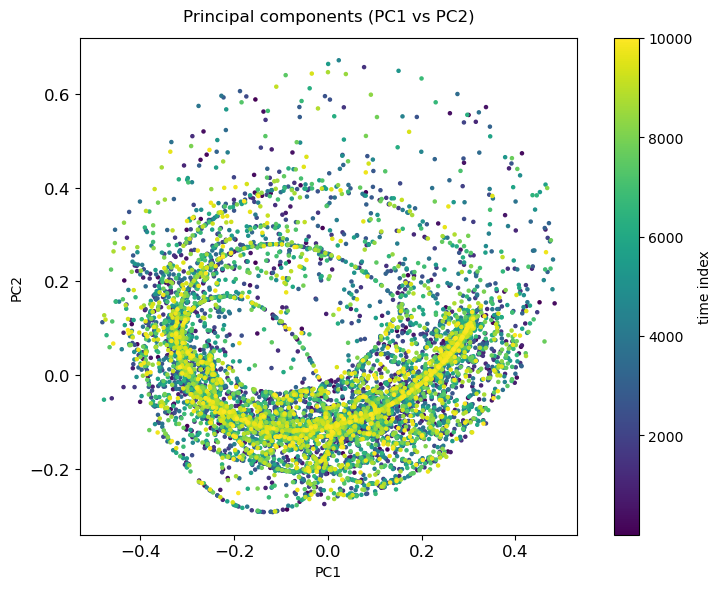

In [ ]:
from sklearn.decomposition import PCA
from scipy.io import loadmat
from sklearn.cluster import KMeans
from scipy.sparse.linalg import eigs, spsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

sinds = np.arange(0, int(2e5), 20)
sinds = sinds[sinds < state_vector.shape[0]]
pts = state_vector[sinds, :].T.copy()
n = pts.shape[1]
pca = PCA()
pca.fit(pts.T)
coeff = pca.components_.T
score = pca.transform(pts.T)
latent = pca.explained_variance_
p0 = pts.mean(axis=1)
PC = pca.components_.dot(pts - p0[:, None])

fig = plt.figure(1, figsize=(8, 6))
sc = plt.scatter(PC[0, :], PC[1, :], s=5,
                 c=np.arange(1, n + 1), cmap='viridis')
cb = plt.colorbar(sc)
cb.set_label('time index')
plt.gca().set_aspect('equal', 'box')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.gca().tick_params(labelsize=12)
plt.title('Principal components (PC1 vs PC2)', pad=12)
plt.tight_layout()

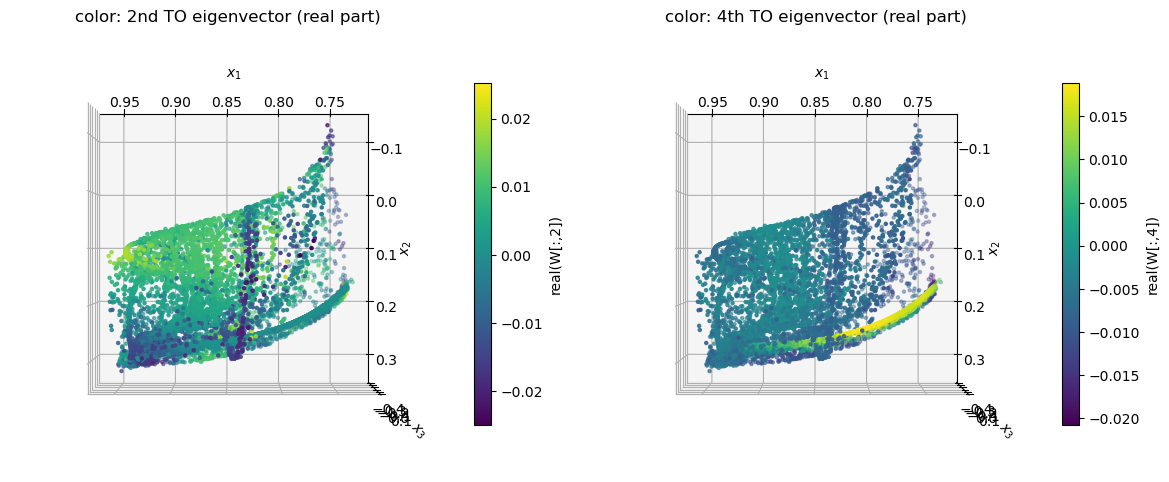

In [ ]:

epsilon = 1e-3
DMM, _ = diffusion_maps_matrix(pts, epsilon)

L = DMM[1:, 0:-1].T

t0 = time.time()
eigvals, W = eigs(L, k=12, which='LM')
t1 = time.time()
TO_evals = eigvals

coords = pts[:, :-1].T  # shape (N-1, 3) for 3D pts
df = build_df(state_vector, dims)

df['TO2_real'] = np.real(W[:, 1])
df['TO2_imag'] = np.imag(W[:, 1])

# (optional) add clustering labels if you want to color by clusters later
features = np.hstack([W.real[:, 1:5], W.imag[:, 1:5]])
km = KMeans(n_clusters=2, n_init=10, random_state=0)
df['km_label'] = km.fit_predict(features)

# Plot the real part of the 2nd TO eigenvector on the pairwise 3D coordinate scatter grid
fig, ax = plot_scatter(df,
                       var_name='TO2_real',
                       cmap='viridis',
                       categorical=False,
                       norm=None,
                       size=4)

df['TO4_real'] = np.real(W[:, 3])
df['TO4_imag'] = np.imag(W[:, 3])

fig, ax = plot_scatter(df,
                       var_name='TO4_real',
                       cmap='viridis',
                       categorical=False,
                       norm=None,
                       size=4)

In [ ]:


fig6 = plt.figure(6, figsize=(12, 4))
ax3 = fig6.add_subplot(131)
c1 = np.sign(np.sum(W[:, 0])) * W[:, 0]
sc3 = ax3.scatter(PC[0, :-1], PC[1, :-1], s=5, c=c1, cmap='viridis')
cbar3 = fig6.colorbar(sc3, ax=ax3)
cbar3.set_label('1st TO eigenvector (signed)')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_title('color: 1st TO eigenvector (real part)', pad=8)
ax3.set_aspect('equal', 'box')


ax4 = fig6.add_subplot(132)
sc4 = ax4.scatter(PC[0, :-1], PC[1, :-1], s=5,
                  c=np.real(W[:, 1]), cmap='viridis')
cbar4 = fig6.colorbar(sc4, ax=ax4)
cbar4.set_label('real(W[:,2])')
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_title('color: 2nd TO eigenvector (real part)', pad=8)
ax4.set_aspect('equal', 'box')


ax5 = fig6.add_subplot(133)
sc5 = ax5.scatter(PC[0, :-1], PC[1, :-1], s=5,
                  c=np.real(W[:, 4]), cmap='viridis')
cbar5 = fig6.colorbar(sc5, ax=ax5)
cbar5.set_label('real(W[:,5])')
ax5.set_xlabel('PC1')
ax5.set_ylabel('PC2')
ax5.set_title('color: 5th TO eigenvector (real part)', pad=8)
ax5.set_aspect('equal', 'box')


fig6.subplots_adjust(wspace=0.4)
plt.tight_layout()


fig7 = plt.figure(7, figsize=(6, 5))
sc7 = plt.scatter(PC[0, :-1], PC[1, :-1], s=5, c=idx_km, cmap='viridis')
cbar7 = plt.colorbar(sc7)
cbar7.set_label('k-means cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('color: kmeans on TO eigenvectors', pad=10)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()

For epsilon = 0.001:


/tmp/ipykernel_73902/3498043989.py:43: ComplexWarning: Casting complex values to real discards the imaginary part
  texit_weigted = float(w @ texit) if texit.size > 0 else np.nan


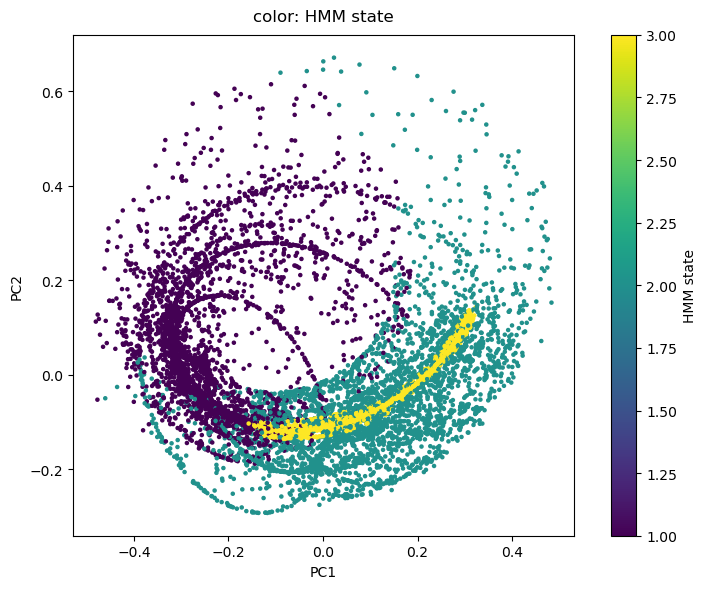

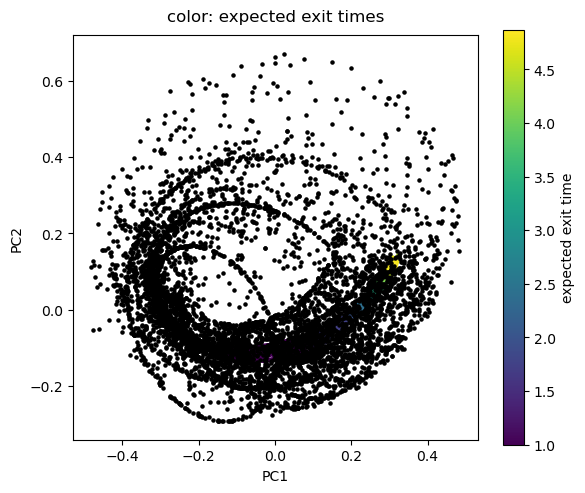

In [26]:

matH = loadmat('CdV_short_dt_2e-4_HMM.mat')
state_assignment = matH['state_assignment'].ravel()

fig8 = plt.figure(8, figsize=(8, 6))
sc8 = plt.scatter(PC[0, :], PC[1, :], s=5,
                  c=state_assignment[sinds], cmap='viridis')
cbar8 = plt.colorbar(sc8)
cbar8.set_label('HMM state')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('color: HMM state', pad=10)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()


k_HMM = 3
ind_in = (np.abs(W[:, 0]) *
          (state_assignment[sinds[:-1]] == k_HMM)).astype(float)
AI_HMM = (np.sign(ind_in) @ (L @ ind_in)) / (ind_in.sum()
                                             if ind_in.sum() != 0 else np.finfo(float).eps)


unique_labels = np.unique(idx_km)
for lab in unique_labels:
    ind_in_km = (np.abs(W[:, 0]) * (idx_km == lab)).astype(float)
    AI_TO = (np.sign(ind_in_km) @ (L @ ind_in_km)) / \
        (ind_in_km.sum() if ind_in_km.sum() != 0 else np.finfo(float).eps)


indM = (state_assignment[sinds[:-1]] == k_HMM)
LM = L[indM][:, indM]
m_comp = int(np.count_nonzero(indM))
I_minus_LM_T = np.eye(m_comp) - LM.T
texit = np.linalg.solve(I_minus_LM_T, np.ones(
    m_comp)) if m_comp > 0 else np.array([])


PCred = PC[:, :-1]
print(f'For epsilon = {epsilon:g}:')
texit_mean = texit.mean() if texit.size > 0 else np.nan
w = W[indM, 0] if texit.size > 0 else np.array([])
w = w / (w.sum() if w.size > 0 and w.sum() != 0 else np.finfo(float).eps)
texit_weigted = float(w @ texit) if texit.size > 0 else np.nan


fig9 = plt.figure(9, figsize=(6, 5))
sc9 = plt.scatter(PCred[0, indM], PCred[1, indM], s=5, c=texit, cmap='viridis')
cbar9 = plt.colorbar(sc9)
cbar9.set_label('expected exit time')
plt.scatter(PCred[0, ~indM], PCred[1, ~indM], s=5, c='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('color: expected exit times', pad=10)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()


plt.show()